In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [ ]:
# Define funções utilizadas

def calcula_retorno(carteira, retornos):
    """
    Calcula o retorno esperado de uma carteira dada uma série de retornos de ativos.
    """
    return np.sum(carteira * retornos)

def calcula_risco(carteira, covariancia):
    """
    Calcula o risco de uma carteira dada a matriz de covariância dos ativos.
    """
    return np.sqrt(np.dot(carteira.T, np.dot(covariancia, carteira)))

def calcula_fronteira_eficiente(retornos, covariancia, num_pontos=500):
    """
    Calcula a fronteira eficiente de uma carteira.
    """
    num_ativos = len(retornos)
    pesos_simulados = np.random.random((num_pontos, num_ativos))
    pesos_simulados /= np.sum(pesos_simulados, axis=1)[:, np.newaxis]

    riscos = np.zeros(num_pontos)
    retornos_carteira = np.zeros(num_pontos)

    for i in range(num_pontos):
        carteira = pesos_simulados[i]
        retornos_carteira[i] = calcula_retorno(carteira, retornos)
        riscos[i] = calcula_risco(carteira, covariancia)

    return riscos, retornos_carteira

def calcula_minima_variancia(retornos, covariancia):
    """
    Calcula a carteira de mínima variância dado os retornos e a matriz de covariância.
    """
    num_ativos = len(retornos)
    ones = np.ones(num_ativos)
    cov_inv = np.linalg.inv(covariancia)
    w = np.dot(cov_inv, ones) / np.dot(ones, np.dot(cov_inv, ones))
    return w

def calcula_carteira_otima(retornos, covariancia, ativo_livre_risco):
    """
    Calcula a carteira ótima utilizando a otimização de Markowitz.
    """
    num_ativos = len(retornos)
    w0 = np.ones(num_ativos) / num_ativos
    bounds = tuple((0, 1) for asset in range(num_ativos))

    def neg_sharpe_ratio(weights, retornos, covariancia):
        r = calcula_retorno(weights, retornos)
        vol = calcula_risco(weights, covariancia)
        return -(r-ativo_livre_risco) / vol

    result = minimize(neg_sharpe_ratio, w0, args=(retornos, covariancia),
                      method='SLSQP', bounds=bounds, constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return result.x

[*********************100%%**********************]  3 of 3 completed


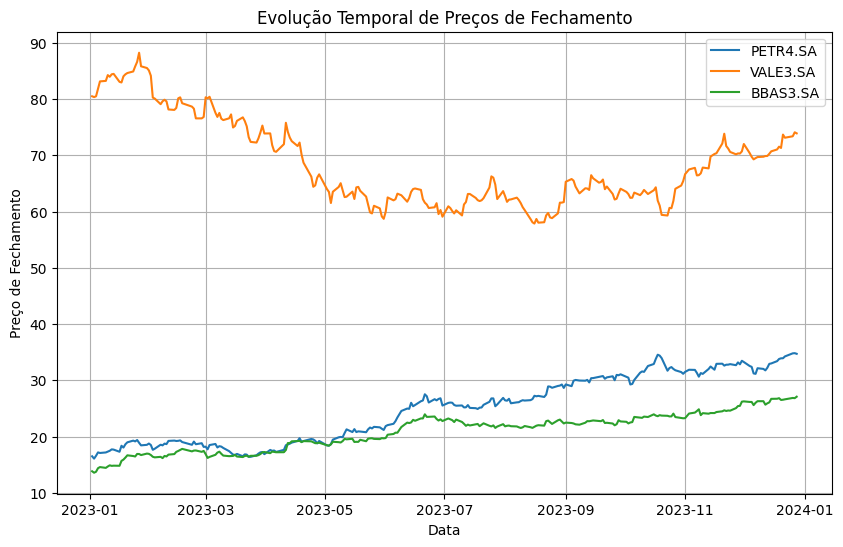

Ticker: PETR4.SA, Retorno: 0.8103, Risco: 0.3183
Ticker: VALE3.SA, Retorno: -0.0517, Risco: 0.2670
Ticker: BBAS3.SA, Retorno: 0.7151, Risco: 0.2424


In [ ]:
# Lista de tickers de ações
tickers = ['PETR4.SA', 'BBAS3.SA']
tickers = ['PETR4.SA', 'VALE3.SA', 'BBAS3.SA']

# Obtendo dados de preços de fechamento utilizando a biblioteca yfinance
precos_fechamento = yf.download(tickers, start='2023-01-01', end='2024-01-01')['Adj Close']

# Calculando os retornos diários
retornos = precos_fechamento.pct_change().mean() * 252  # Retorna os retornos médios anualizados
covariancia = precos_fechamento.pct_change().cov() * 252  # Retorna a covariância anualizada

# Plotagem do gráfico de evolução temporal de cada ticker
plt.figure(figsize=(10, 6))
for ticker in tickers:
    plt.plot(precos_fechamento.index, precos_fechamento[ticker], label=ticker)

plt.title('Evolução Temporal de Preços de Fechamento')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid(True)
plt.show()

# Imprimir o risco e o retorno de cada ativo no período
for ticker in tickers:
    retorno = precos_fechamento[ticker].pct_change().mean() * 252
    risco = precos_fechamento[ticker].pct_change().std() * np.sqrt(252)
    print(f"Ticker: {ticker}, Retorno: {retorno:.4f}, Risco: {risco:.4f}")


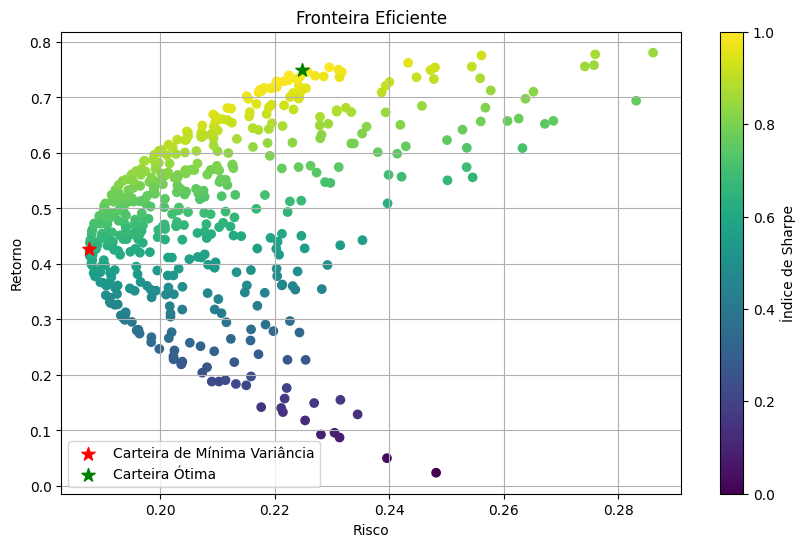

Carteira de Mínima Variância:
PETR4.SA: 0.47
VALE3.SA: 0.14
BBAS3.SA: 0.39
Retorno: 0.4266
Risco: 0.1877

Carteira Ótima:
PETR4.SA: 0.63
VALE3.SA: 0.37
BBAS3.SA: 0.00
Retorno: 0.7500
Risco: 0.2248


In [ ]:
# Define ativo livre de risco
ativo_livre_risco = 0.0290

# Calcula a fronteira eficiente
riscos_fronteira, retornos_fronteira = calcula_fronteira_eficiente(retornos, covariancia)

# Calcula a carteira de mínima variância
pesos_min_var = calcula_minima_variancia(retornos, covariancia)
retorno_min_var = calcula_retorno(pesos_min_var, retornos)
risco_min_var = calcula_risco(pesos_min_var, covariancia)

# Calcula a carteira ótima
pesos_otima = calcula_carteira_otima(retornos, covariancia, ativo_livre_risco)
retorno_otima = calcula_retorno(pesos_otima, retornos)
risco_otima = calcula_risco(pesos_otima, covariancia)

# Plota o gráfico risco versus retorno
plt.figure(figsize=(10, 6))
plt.scatter(riscos_fronteira, retornos_fronteira, c=(retornos_fronteira - ativo_livre_risco)/ riscos_fronteira, marker='o')
plt.scatter(risco_min_var, retorno_min_var, color='red', marker='*', s=100, label='Carteira de Mínima Variância')
plt.scatter(risco_otima, retorno_otima, color='green', marker='*', s=100, label='Carteira Ótima')
plt.title('Fronteira Eficiente')
plt.xlabel('Risco')
plt.ylabel('Retorno')
plt.colorbar(label='Índice de Sharpe')
plt.legend()
plt.grid(True)
plt.show()

# Imprime a composição, risco e retorno da carteira de mínima variância
print("Carteira de Mínima Variância:")
for ticker, peso in zip(tickers, pesos_min_var):
    print(f"{ticker}: {peso:.2f}")
print(f"Retorno: {retorno_min_var:.4f}")
print(f"Risco: {risco_min_var:.4f}")

# Imprime a composição, risco e retorno da carteira ótima
print("\nCarteira Ótima:")
for ticker, peso in zip(tickers, pesos_otima):
    print(f"{ticker}: {peso:.2f}")
print(f"Retorno: {retorno_otima:.4f}")
print(f"Risco: {risco_otima:.4f}")
